# Assignment 5 (TensorFlow / Keras) - Team 2 - Pranitee Pramod Majukar - Moin Soorya

## Importing Libraries

In [1]:
import re
import nltk
from nltk.tokenize import sent_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
#%%time
from collections import Counter
from nltk import ngrams
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Bidirectional

C:\Users\moins\anaconda3\envs\pymc_env\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## Cleaning data

In [2]:
# Load the file
unknown_token = "UNKNOWN_TOKEN"
sentence_start_token = "SENTENCE_START"
sentence_end_token = "SENTENCE_END"

# Define your regex patterns
alphabets = r"([A-Za-z])"
prefixes = r"(Mr|St|Mrs|Ms|Dr)[.]"
suffixes = r"(Inc|Ltd|Jr|Sr|Co)"
starters = r"(Mr|Mrs|Ms|Dr|Prof|Capt|Cpt|Lt|He\s|She\s|It\s|They\s|Their\s|Our\s|We\s|But\s|However\s|That\s|This\s|Wherever)"
acronyms = r"([A-Z][.][A-Z][.](?:[A-Z][.])?)"
websites = r"[.](com|net|org|io|gov|edu|me)"
digits = r"([0-9])"

# Function to clean up Roman numerals
def clean_roman_numerals(text):
    roman_numerals = r'\b(?:[IVXLCDM]+)\b'
    return re.sub(roman_numerals, '', text)

# Read the text file with UTF-8 encoding and handle errors
print("Reading txt file...")

with open(r"C:\Users\moins\OneDrive - Northeastern University\Documents\Neural Networks\Assignment 5\sherlockbook.txt", 'r', encoding='utf-8', errors='replace') as f:
    text = f.read()

# Replace unwanted characters and apply regex replacements
text = (text.replace(",", "")
           .replace(":", "")
           .replace(";", "")
           .replace("’", " ")  # Remove curly single quote
           .replace("'", " ")  # Remove straight single quote
           .replace("_", "")  # Remove underscores
           .replace("\"", "")  # Remove straight double quotes
           .replace("“", "")   # Remove left curly quote
           .replace("”", "")   # Remove right curly quote
           .replace("?\n", ".\n")
           .replace("!\n", ".\n")
           .replace("?", "")
           .replace("!", "")
           #.replace("'"," ")
           .replace("—"," ")
           .replace("(",""))
# Replace acronyms, prefixes, suffixes, etc.
text = re.sub(acronyms, lambda x: x.group(0).replace(".", ""), text)
text = re.sub(prefixes, lambda x: x.group(1) + " ", text)
text = re.sub(suffixes, lambda x: " " + x.group(1), text)
text = re.sub(websites, "", text)  # Removing website URLs
#text = re.sub(digits, lambda x: f" {x.group(0)} ", text)  # Surround digits with spaces

# Replace "I " with "i " and clean Roman numerals
text = text.replace('I ', 'i ')
text = clean_roman_numerals(text)

# Combine multiple spaces into one and strip leading/trailing spaces
_RE_COMBINE_WHITESPACE = re.compile(r"\s+")
text = _RE_COMBINE_WHITESPACE.sub(" ", text).strip()

print('Text cleaning done!')

Reading txt file...
Text cleaning done!


In [3]:
text

'To Sherlock Holmes she is always the woman. i have seldom heard him mention her under any other name. In his eyes she eclipses and predominates the whole of her sex. It was not that he felt any emotion akin to love for Irene Adler. All emotions and that one particularly were abhorrent to his cold precise but admirably balanced mind. He was i take it the most perfect reasoning and observing machine that the world has seen but as a lover he would have placed himself in a false position. He never spoke of the softer passions save with a gibe and a sneer. They were admirable things for the observer excellent for drawing the veil from men s motives and actions. But for the trained reasoner to admit such intrusions into his own delicate and finely adjusted temperament was to introduce a distracting factor which might throw a doubt upon all his mental results. Grit in a sensitive instrument or a crack in one of his own high-power lenses would not be more disturbing than a strong emotion in a

In [4]:
def clean_roman_numerals(text):
    pattern = r"\b(?=[MDCLXVIΙ])M{0,4}(CM|CD|D?C{0,3})(XC|XL|L?X{0,3})([IΙ]X|[IΙ]V|V?[IΙ]{0,3})\b\.?"
    return re.sub(pattern, '', text)

In [5]:
clean_roman_numerals(text)

'To Sherlock Holmes she is always the woman. i have seldom heard him mention her under any other name. In his eyes she eclipses and predominates the whole of her sex. It was not that he felt any emotion akin to love for Irene Adler. All emotions and that one particularly were abhorrent to his cold precise but admirably balanced mind. He was i take it the most perfect reasoning and observing machine that the world has seen but as a lover he would have placed himself in a false position. He never spoke of the softer passions save with a gibe and a sneer. They were admirable things for the observer excellent for drawing the veil from men s motives and actions. But for the trained reasoner to admit such intrusions into his own delicate and finely adjusted temperament was to introduce a distracting factor which might throw a doubt upon all his mental results. Grit in a sensitive instrument or a crack in one of his own high-power lenses would not be more disturbing than a strong emotion in a

## Plotting word cloud

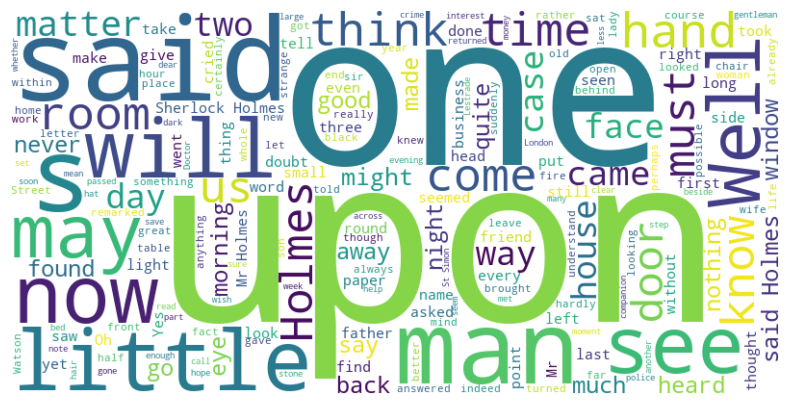

In [6]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off axis labels
plt.show()

In [7]:
# Tokenize text into sentences
sentences = sent_tokenize(text)

# Add sentence start and end tokens, and print sentence details
for i, sentence in enumerate(sentences):
    # Add start and end tokens to each sentence
    sentence_with_tokens = f"{sentence_start_token} {sentence} {sentence_end_token}"
    
    # Split the sentence into words to calculate the length
    words = sentence.split()
    
    print(f"Sentence {i + 1}:")
    print(f"Start: {sentence_start_token}")
    print(f"End: {sentence_end_token}")
    print(f"Length: {len(words)} words")
    print(f"Sentence with Tokens: {sentence_with_tokens}")
    print("-" * 50)


Sentence 1:
Start: SENTENCE_START
End: SENTENCE_END
Length: 8 words
Sentence with Tokens: SENTENCE_START To Sherlock Holmes she is always the woman. SENTENCE_END
--------------------------------------------------
Sentence 2:
Start: SENTENCE_START
End: SENTENCE_END
Length: 11 words
Sentence with Tokens: SENTENCE_START i have seldom heard him mention her under any other name. SENTENCE_END
--------------------------------------------------
Sentence 3:
Start: SENTENCE_START
End: SENTENCE_END
Length: 12 words
Sentence with Tokens: SENTENCE_START In his eyes she eclipses and predominates the whole of her sex. SENTENCE_END
--------------------------------------------------
Sentence 4:
Start: SENTENCE_START
End: SENTENCE_END
Length: 14 words
Sentence with Tokens: SENTENCE_START It was not that he felt any emotion akin to love for Irene Adler. SENTENCE_END
--------------------------------------------------
Sentence 5:
Start: SENTENCE_START
End: SENTENCE_END
Length: 16 words
Sentence with Tokens

In [8]:
bigram_counts = Counter(ngrams(text.split(), 2))
bigram_counts.most_common(15) 

[(('of', 'the'), 699),
 (('in', 'the'), 482),
 (('to', 'the'), 299),
 (('i', 'have'), 279),
 (('that', 'i'), 238),
 (('at', 'the'), 224),
 (('upon', 'the'), 195),
 (('to', 'be'), 192),
 (('and', 'the'), 187),
 (('and', 'i'), 186),
 (('with', 'a'), 174),
 (('i', 'am'), 171),
 (('of', 'a'), 169),
 (('i', 'was'), 168),
 (('It', 'is'), 164)]

In [9]:
trigram_counts = Counter(ngrams(text.split(), 3))
trigram_counts.most_common(15)

[(('one', 'of', 'the'), 43),
 (('i', 'think', 'that'), 41),
 (('that', 'it', 'was'), 36),
 (('i', 'do', 'not'), 33),
 (('out', 'of', 'the'), 33),
 (('that', 'i', 'have'), 33),
 (('that', 'it', 'is'), 32),
 (('It', 'was', 'a'), 32),
 (('that', 'he', 'had'), 30),
 (('that', 'he', 'was'), 30),
 (('that', 'i', 'had'), 27),
 (('that', 'i', 'was'), 27),
 (('It', 'is', 'a'), 26),
 (('in', 'front', 'of'), 26),
 (('i', 'have', 'no'), 25)]

In [10]:
quadgram_counts = Counter(ngrams(text.replace('&', 'i').split(), 4))
quadgram_counts.most_common(20)

[(('i', 'have', 'no', 'doubt'), 15),
 (('have', 'no', 'doubt', 'that'), 14),
 (('i', 'think', 'that', 'i'), 13),
 (('to', 'me', 'to', 'be'), 11),
 (('i', 'do', 'not', 'know'), 11),
 (('in', 'front', 'of', 'the'), 10),
 (('i', 'do', 'not', 'think'), 10),
 (('of', 'a', 'man', 'who'), 9),
 (('a', 'man', 'who', 'is'), 9),
 (('i', 'beg', 'that', 'you'), 9),
 (('the', 'corner', 'of', 'the'), 8),
 (('one', 'of', 'the', 'most'), 8),
 (('it', 'seemed', 'to', 'me'), 8),
 (('that', 'it', 'would', 'be'), 8),
 (('in', 'the', 'direction', 'of'), 8),
 (('the', 'direction', 'of', 'the'), 8),
 (('beg', 'that', 'you', 'will'), 8),
 (('i', 'think', 'Watson', 'that'), 7),
 (('from', 'one', 'to', 'the'), 7),
 (('one', 'to', 'the', 'other'), 7)]

In [11]:
decagram_counts = Counter(ngrams(text.split(), 10))
decagram_counts.most_common(10)

[(('‘and',
   'half',
   'a',
   'sovereign',
   'if',
   'you',
   'reach',
   'it',
   'in',
   'twenty'),
  2),
 (('half',
   'a',
   'sovereign',
   'if',
   'you',
   'reach',
   'it',
   'in',
   'twenty',
   'minutes.'),
  2),
 (('Dr',
   'Watson',
   'before',
   'whom',
   'you',
   'can',
   'speak',
   'as',
   'freely',
   'as'),
  2),
 (('Watson',
   'before',
   'whom',
   'you',
   'can',
   'speak',
   'as',
   'freely',
   'as',
   'before'),
  2),
 (('before',
   'whom',
   'you',
   'can',
   'speak',
   'as',
   'freely',
   'as',
   'before',
   'myself.'),
  2),
 (('To',
   'Sherlock',
   'Holmes',
   'she',
   'is',
   'always',
   'the',
   'woman.',
   'i',
   'have'),
  1),
 (('Sherlock',
   'Holmes',
   'she',
   'is',
   'always',
   'the',
   'woman.',
   'i',
   'have',
   'seldom'),
  1),
 (('Holmes',
   'she',
   'is',
   'always',
   'the',
   'woman.',
   'i',
   'have',
   'seldom',
   'heard'),
  1),
 (('she',
   'is',
   'always',
   'the',
   'woma

## Tokenizing sentences

In [12]:
# Tokenization and preparing sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

# Convert sentences to sequences
sequences = tokenizer.texts_to_sequences(sentences)

# Vocabulary size (total number of unique tokens)
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding
print(f"Vocabulary size: {vocab_size}")

# Print a sample of the sequences
print("Sample sequence:", sequences[:2])


Vocabulary size: 8013
Sample sequence: [[4, 132, 33, 37, 14, 217, 1, 182], [3, 16, 1552, 115, 35, 3151, 36, 277, 102, 94, 206]]


In [13]:
# Prepare input (X) and output (Y)
max_sequence_len = max([len(seq) for seq in sequences])  # Find max sequence length
input_sequences = []

# Create input sequences and their corresponding labels
for seq in sequences:
    for i in range(1, len(seq)):
        n_gram_sequence = seq[:i+1]
        input_sequences.append(n_gram_sequence)

# Pad the sequences to ensure uniform input shape
input_sequences = pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')

# Split into input (X) and output (Y)
X, y = input_sequences[:, :-1], input_sequences[:, -1]

# One-hot encode the output labels
y = np.array(y)

print(f"Input shape (X): {X.shape}")
print(f"Output shape (y): {y.shape}")


Input shape (X): (99468, 101)
Output shape (y): (99468,)


# RNN Model approach with 2 Layer approach

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Bidirectional
import warnings
warnings.filterwarnings('ignore')

# Define the RNN model
model = Sequential()
model.add(Embedding(vocab_size, 150, input_length=max_sequence_len - 1))  # Embedding layer
model.add(Bidirectional(SimpleRNN(150, return_sequences=True)))  # Corrected to SimpleRNN
model.add(SimpleRNN(200, return_sequences=False))  # RNN layer
model.add(Dense(vocab_size, activation='softmax'))  # Output layer

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [16]:
# Train the RNN model
history = model.fit(X, y, epochs=30, verbose=1)
model.summary()

Epoch 1/30
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 263s 84ms/step - accuracy: 0.0698 - loss: 6.5796
Epoch 2/30
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 263s 85ms/step - accuracy: 0.1305 - loss: 5.5574
Epoch 3/30
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 265s 85ms/step - accuracy: 0.1467 - loss: 5.2248
Epoch 4/30
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 266s 85ms/step - accuracy: 0.1614 - loss: 4.9327
Epoch 5/30
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 269s 87ms/step - accuracy: 0.1727 - loss: 4.6580
Epoch 6/30
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 272s 87ms/step - accuracy: 0.1860 - loss: 4.4288
Epoch 7/30
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 272s 87ms/step - accuracy: 0.1994 - loss: 4.2186
Epoch 8/30
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 272s 88ms/step - accuracy: 0.2145 - loss: 4.0176
Epoch 9/30
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 287s 92ms/step - accuracy: 0.2262 - loss: 3.8503
Epoch 10/30
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 266s 86ms/step - accuracy: 0.2398 - loss: 3.6920
Epoch 11/30
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 263s 85ms/step - accuracy: 0.2603 - loss: 3.54

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 101, 150)            │       1,201,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 101, 300)            │          90,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 200)                 │         100,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8013)                │       1,610,613 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,009,191 (34.37 MB)

 Trainable params: 3,003,063 (11.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,006,128 (22.91 MB)

## Predictions

In [17]:
# Predict the next word
def predict_next_word(model, tokenizer, seed_text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    
    predicted_word_index = np.argmax(predicted, axis=-1)
    predicted_word = ""
    
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            predicted_word = word
            break
    return predicted_word

# Example usage: Generate a sentence
seed_text = "To Sherlock Holmes"
next_word = predict_next_word(model, tokenizer, seed_text, max_sequence_len)
print(f"Next word prediction: {next_word}")


Next word prediction: she


In [19]:
# Generate a sequence of words
def generate_text(model, tokenizer, seed_text, max_sequence_len, num_words):
    for _ in range(num_words):
        next_word = predict_next_word(model, tokenizer, seed_text, max_sequence_len)
        seed_text += " " + next_word
    return seed_text

# Example usage: Generate a sequence of 20 words
generated_sentence = generate_text(model, tokenizer, "To Sherlock Holmes", max_sequence_len, 50)
print(f"Generated sentence: {generated_sentence}")


Generated sentence: To Sherlock Holmes she cried glancing round and threw open the door of the clergyman find his stick and blunt weapon upon his face floor and the murdering and driving rapidly and pulled his eyes into a hearty fit of laughter to control that i was saving a touch of expectancy cross coming


## Saving the model weights with 2 RNN Layer

In [20]:
warnings.filterwarnings('ignore')
saved_model = model.save("C:/Users/moins/OneDrive - Northeastern University/Documents/Neural Networks/Assignment 5/model_2Layer.h5")

In [21]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath = r"C:/Users/moins/OneDrive - Northeastern University/Documents/Neural Networks/Assignment 5/model_2Layer.weights.h5",
    save_weights_only=True,
    monitor="loss",
    save_best_only=True,
)

In [22]:
warnings.filterwarnings('ignore')
saved_model = tf.keras.models.load_model(r"C:/Users/moins/OneDrive - Northeastern University/Documents/Neural Networks/Assignment 5/model_2Layer.h5")

# Predictions with RNN Saved Model with 2 Layer approach

In [23]:
# Predict the next word
def predict_next_word(model, tokenizer, seed_text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    
    predicted_word_index = np.argmax(predicted, axis=-1)
    predicted_word = ""
    
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            predicted_word = word
            break
    return predicted_word

# Example usage: Generate a sentence
seed_text = "To Sherlock Holmes"
next_word = predict_next_word(saved_model, tokenizer, seed_text, max_sequence_len)
print(f"Next word prediction: {next_word}")


Next word prediction: she


In [29]:
# Generate a sequence of words
def generate_text(model, tokenizer, seed_text, max_sequence_len, num_words):
    for _ in range(num_words):
        next_word = predict_next_word(model, tokenizer, seed_text, max_sequence_len)
        seed_text += " " + next_word
    return seed_text

# Example usage: Generate a sequence of 50 words
generated_sentence = generate_text(saved_model, tokenizer, "To Sherlock Holmes", max_sequence_len, 50)
print(f"Generated sentence: {generated_sentence}")


Generated sentence: To Sherlock Holmes she cried glancing round and threw open the door of the clergyman find his stick and blunt weapon upon his face floor and the murdering and driving rapidly and pulled his eyes into a hearty fit of laughter to control that i was saving a touch of expectancy cross coming


In [45]:
import numpy as np

def predict_next_word(model, tokenizer, seed_text, max_sequence_len, temperature=1.0):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = np.pad(token_list, (max_sequence_len - len(token_list), 0), 'constant')
    token_list = np.expand_dims(token_list, axis=0)
    
    predictions = model.predict(token_list, verbose=0)[0]
    # Apply temperature to predictions
    predictions = np.log(predictions + 1e-7) / temperature
    exp_preds = np.exp(predictions)
    predictions = exp_preds / np.sum(exp_preds)
    
    # Randomly sample a word from the probability distribution
    next_word_index = np.random.choice(len(predictions), p=predictions)
    next_word = tokenizer.index_word[next_word_index]
    
    return next_word

def generate_text(model, tokenizer, seed_text, max_sequence_len, num_words, temperature=1.0):
    for _ in range(num_words):
        next_word = predict_next_word(model, tokenizer, seed_text, max_sequence_len, temperature)
        seed_text += " " + next_word
    return seed_text

# Generate 7-8 versions with different predictions
def generate_multiple_versions(model, tokenizer, seed_text, max_sequence_len, num_words, num_versions=8, temperature=1.0):
    versions = []
    for _ in range(num_versions):
        new_seed_text = seed_text  # Reset seed text for each version
        generated_sentence = generate_text(model, tokenizer, new_seed_text, max_sequence_len, num_words, temperature)
        versions.append(generated_sentence)
    return versions

# Example usage
generated_sentences = generate_multiple_versions(saved_model, tokenizer, "He was still deeply attracted by the study of crime", max_sequence_len, 30, 8, temperature=0.7)
for i, sentence in enumerate(generated_sentences):
    print(f"Generated sentence {i+1}: {sentence}")


Generated sentence 1: He was still deeply attracted by the study of crime i followed over the newspapers for wear as true as cunning than that i should never see and she cried next day and to see my position to the fact
Generated sentence 2: He was still deeply attracted by the study of crime and yet he sat into the bedroom and the rabbit one of court well continually from his face which he had picked up in the two guardsmen who ordered the
Generated sentence 3: He was still deeply attracted by the study of crime and yet he sat into the same and which happened to wake an american and original observer that he was afraid for us to break his hand as we entered
Generated sentence 4: He was still deeply attracted by the study of crime he answered his face and down his face turned down and down the street onto the stones came slowly across the sky and a man had an band with a
Generated sentence 5: He was still deeply attracted by the study of crime is there and i began to relieve her manner

## Prdictions with RNN Saved model with 1 Layer

In [25]:
warnings.filterwarnings('ignore')
saved_model_70acc = tf.keras.models.load_model(r"C:/Users/moins/OneDrive - Northeastern University/Documents/Neural Networks/Assignment 5/model.h5")

In [26]:
# Predict the next word
def predict_next_word(model, tokenizer, seed_text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    
    predicted_word_index = np.argmax(predicted, axis=-1)
    predicted_word = ""
    
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            predicted_word = word
            break
    return predicted_word

# Example usage: Generate a sentence
seed_text = "To Sherlock Holmes"
next_word = predict_next_word(saved_model_70acc, tokenizer, seed_text, max_sequence_len)
print(f"Next word prediction: {next_word}")


Next word prediction: was


In [28]:
# Generate a sequence of words
def generate_text(model, tokenizer, seed_text, max_sequence_len, num_words):
    for _ in range(num_words):
        next_word = predict_next_word(model, tokenizer, seed_text, max_sequence_len)
        seed_text += " " + next_word
    return seed_text

# Example usage: Generate a sequence of 50 words
generated_sentence = generate_text(saved_model_70acc, tokenizer, "To Sherlock Holmes", max_sequence_len, 50)
print(f"Generated sentence: {generated_sentence}")


Generated sentence: To Sherlock Holmes was keenly at the king of bohemia said he that the result of causing the fire and was in his chair and paced up breakfast with a very long and there is a possible bearing between the street the tall and of the union jack with a black or cry


In [47]:
import numpy as np

def predict_next_word(model, tokenizer, seed_text, max_sequence_len, temperature=1.0):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = np.pad(token_list, (max_sequence_len - len(token_list), 0), 'constant')
    token_list = np.expand_dims(token_list, axis=0)
    
    predictions = model.predict(token_list, verbose=0)[0]
    # Apply temperature to predictions
    predictions = np.log(predictions + 1e-7) / temperature
    exp_preds = np.exp(predictions)
    predictions = exp_preds / np.sum(exp_preds)
    
    # Randomly sample a word from the probability distribution
    next_word_index = np.random.choice(len(predictions), p=predictions)
    next_word = tokenizer.index_word[next_word_index]
    
    return next_word

def generate_text(model, tokenizer, seed_text, max_sequence_len, num_words, temperature=1.0):
    for _ in range(num_words):
        next_word = predict_next_word(model, tokenizer, seed_text, max_sequence_len, temperature)
        seed_text += " " + next_word
    return seed_text

# Generate 7-8 versions with different predictions
def generate_multiple_versions(model, tokenizer, seed_text, max_sequence_len, num_words, num_versions=8, temperature=1.0):
    versions = []
    for _ in range(num_versions):
        new_seed_text = seed_text  # Reset seed text for each version
        generated_sentence = generate_text(model, tokenizer, new_seed_text, max_sequence_len, num_words, temperature)
        versions.append(generated_sentence)
    return versions

# Example usage
generated_sentences = generate_multiple_versions(saved_model_70acc, tokenizer, "He was still deeply attracted by the study of crime", max_sequence_len, 30, 8, temperature=0.7)
for i, sentence in enumerate(generated_sentences):
    print(f"Generated sentence {i+1}: {sentence}")


Generated sentence 1: He was still deeply attracted by the study of crime entirely ‘ cooee before the house up though the letter and placed what it is concerned in an instant that i am sure forgive anything of mind and what we
Generated sentence 2: He was still deeply attracted by the study of crime and how i should be entirely is very probable that moment i came to had a little that a friend and even robberies which really really can t but i
Generated sentence 3: He was still deeply attracted by the study of crime tut st simon announced in the lantern and my hat and i have a third in my room cast effect the way of the barmaid station yourself close at the
Generated sentence 4: He was still deeply attracted by the study of crime the personality of his long thin nose remarked new and gentle above there for a retort greeting caused have given prominence the photograph is i am sure by you are
Generated sentence 5: He was still deeply attracted by the study of crime utter stillness and ext

# Glove Embeddeding approach with RNN 1 Layer

In [26]:
# Step 2: Load the GloVe embeddings into a dictionary
import numpy as np
 
# Path to the GloVe file (adjust based on your download location)
glove_file_path = 'C:/Users/moins/OneDrive - Northeastern University/Documents/Neural Networks/L6D2/glove.6B.100d.txt'
 
# Initialize an empty dictionary to hold the embeddings
embeddings_index = {}
 
# Load the GloVe file and fill the embeddings_index dictionary
with open(glove_file_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]  # The first entry is the word
        coefs = np.asarray(values[1:], dtype='float32')  # The rest are the vector values
        embeddings_index[word] = coefs
 
print(f'Loaded {len(embeddings_index)} word vectors.')

Loaded 400000 word vectors.


In [27]:
embedding_dim = 100  # Using the 100-dimensional GloVe vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim))  # Initialize the embedding matrix with zeros
for word, index in tokenizer.word_index.items():
    if index < vocab_size:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[index] = embedding_vector  # Words not found in the GloVe corpus will be all zeros
print("Embedding matrix created.")

Embedding matrix created.


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
 
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_sequence_len - 1, trainable=False))  # Set trainable to False to keep GloVe embeddings static
model.add(SimpleRNN(250, return_sequences=False))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

In [32]:
from tensorflow.keras.callbacks import EarlyStopping
history = model.fit(X, y, epochs=80, verbose=1)

Epoch 1/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 206s 66ms/step - loss: 6.4602
Epoch 2/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 203s 65ms/step - loss: 5.3284
Epoch 3/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 204s 66ms/step - loss: 4.7963
Epoch 4/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 201s 65ms/step - loss: 4.3890
Epoch 5/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 202s 65ms/step - loss: 4.0512
Epoch 6/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 202s 65ms/step - loss: 3.8364
Epoch 7/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 201s 65ms/step - loss: 3.6893
Epoch 8/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 203s 65ms/step - loss: 3.4518
Epoch 9/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 201s 65ms/step - loss: 3.4255
Epoch 10/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 201s 65ms/step - loss: 3.3404
Epoch 11/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 203s 65ms/step - loss: 3.3213
Epoch 12/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 201s 65ms/step - loss: 3.5362
Epoch 13/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 201s 65ms/step - loss: 3.1705
Epoch 14/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 204s 66ms/step - 

In [33]:
warnings.filterwarnings('ignore')
saved_model_glove_1Lay = model.save("C:/Users/moins/OneDrive - Northeastern University/Documents/Neural Networks/Assignment 5/saved_model_glove_1Lay.h5")

In [34]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath = r"C:/Users/moins/OneDrive - Northeastern University/Documents/Neural Networks/Assignment 5/saved_model_glove_1Lay.weights.h5",
    save_weights_only=True,
    monitor="loss",
    save_best_only=True,
)

In [35]:
warnings.filterwarnings('ignore')
saved_model_glove_1Lay = tf.keras.models.load_model(r"C:/Users/moins/OneDrive - Northeastern University/Documents/Neural Networks/Assignment 5/saved_model_glove_1Lay.h5")

In [36]:
# Predict the next word
def predict_next_word(model, tokenizer, seed_text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    
    predicted_word_index = np.argmax(predicted, axis=-1)
    predicted_word = ""
    
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            predicted_word = word
            break
    return predicted_word

# Example usage: Generate a sentence
seed_text = "To Sherlock Holmes"
next_word = predict_next_word(saved_model_glove_1Lay, tokenizer, seed_text, max_sequence_len)
print(f"Next word prediction: {next_word}")


Next word prediction: was


In [37]:
# Generate a sequence of words
def generate_text(model, tokenizer, seed_text, max_sequence_len, num_words):
    for _ in range(num_words):
        next_word = predict_next_word(model, tokenizer, seed_text, max_sequence_len)
        seed_text += " " + next_word
    return seed_text

# Example usage: Generate a sequence of 50 words
generated_sentence = generate_text(saved_model_glove_1Lay, tokenizer, "To Sherlock Holmes", max_sequence_len, 50)
print(f"Generated sentence: {generated_sentence}")


Generated sentence: To Sherlock Holmes was a scotch bonnet and the box of the trap of the easy that i could not risk the loss of events which i could make appear to be a most interesting of the matter of the kind problem which occurred is why could have lived rent free to the


In [42]:
import numpy as np

def predict_next_word(model, tokenizer, seed_text, max_sequence_len, temperature=1.0):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = np.pad(token_list, (max_sequence_len - len(token_list), 0), 'constant')
    token_list = np.expand_dims(token_list, axis=0)
    
    predictions = model.predict(token_list, verbose=0)[0]
    # Apply temperature to predictions
    predictions = np.log(predictions + 1e-7) / temperature
    exp_preds = np.exp(predictions)
    predictions = exp_preds / np.sum(exp_preds)
    
    # Randomly sample a word from the probability distribution
    next_word_index = np.random.choice(len(predictions), p=predictions)
    next_word = tokenizer.index_word[next_word_index]
    
    return next_word

def generate_text(model, tokenizer, seed_text, max_sequence_len, num_words, temperature=1.0):
    for _ in range(num_words):
        next_word = predict_next_word(model, tokenizer, seed_text, max_sequence_len, temperature)
        seed_text += " " + next_word
    return seed_text

# Generate 7-8 versions with different predictions
def generate_multiple_versions(model, tokenizer, seed_text, max_sequence_len, num_words, num_versions=8, temperature=1.0):
    versions = []
    for _ in range(num_versions):
        new_seed_text = seed_text  # Reset seed text for each version
        generated_sentence = generate_text(model, tokenizer, new_seed_text, max_sequence_len, num_words, temperature)
        versions.append(generated_sentence)
    return versions

# Example usage
generated_sentences = generate_multiple_versions(saved_model_glove_1Lay, tokenizer, "He was still deeply attracted by the study of crime", max_sequence_len, 30, 8, temperature=0.7)
for i, sentence in enumerate(generated_sentences):
    print(f"Generated sentence {i+1}: {sentence}")


Generated sentence 1: He was still deeply attracted by the study of crime and occupied by him with the intention of wishing me to i was awakened by the time when the betrothal of making to us or i reached the end of
Generated sentence 2: He was still deeply attracted by the study of crime which can hardly be an bad of the sign of the darlington substitution scandal which were frequently allowed us and i have only single handed of the high road near
Generated sentence 3: He was still deeply attracted by the study of crime should be determined to give me the letter of proosia and i believe that she carried a little and the former court when ever heard from the afternoon step away
Generated sentence 4: He was still deeply attracted by the study of crime might set the money of dr grimesby roylott gentlemen look that arrived to lead the fire of the fire and quick march every afternoon and send her to the nature
Generated sentence 5: He was still deeply attracted by the study of crime in the

## Glove Embedding with 2 Simple RNN Layer

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, LSTM, Dropout

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_sequence_len - 1, trainable=False))  # Set trainable to False to keep GloVe embeddings static
model.add(SimpleRNN(200, return_sequences=False))
model.add(SimpleRNN(150,return_sequences=False))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

# Step 5: Train the mod
history = model.fit(X, y, epochs=80, verbose=1, callbacks=[early_stopping])


Epoch 1/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 463s 148ms/step - accuracy: 0.0666 - loss: 6.5799
Epoch 2/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 467s 150ms/step - accuracy: 0.1139 - loss: 5.7096
Epoch 3/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 454s 146ms/step - accuracy: 0.1317 - loss: 5.3660
Epoch 4/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 461s 148ms/step - accuracy: 0.1399 - loss: 5.1121
Epoch 5/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 461s 148ms/step - accuracy: 0.1499 - loss: 4.8759
Epoch 6/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 454s 146ms/step - accuracy: 0.1589 - loss: 4.7060
Epoch 7/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 461s 148ms/step - accuracy: 0.1652 - loss: 4.5409
Epoch 8/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 470s 151ms/step - accuracy: 0.1733 - loss: 4.4143
Epoch 9/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 466s 150ms/step - accuracy: 0.1841 - loss: 4.2744
Epoch 10/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 471s 152ms/step - accuracy: 0.1894 - loss: 4.1728
Epoch 11/80
3109/3109 ━━━━━━━━━━━━━━━━━━━━ 466s 150ms/step - accuracy: 0.1966 -

In [116]:
warnings.filterwarnings('ignore')
saved_model_glove = model.save("C:/Users/moins/OneDrive - Northeastern University/Documents/Neural Networks/Assignment 5/model_glove.h5")

In [117]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath = r"C:/Users/moins/OneDrive - Northeastern University/Documents/Neural Networks/Assignment 5/model_glove.weights.h5",
    save_weights_only=True,
    monitor="loss",
    save_best_only=True,
)

In [13]:
warnings.filterwarnings('ignore')
saved_model_glove = tf.keras.models.load_model(r"C:/Users/moins/OneDrive - Northeastern University/Documents/Neural Networks/Assignment 5/model_glove.h5")

In [14]:
# Predict the next word
def predict_next_word(model, tokenizer, seed_text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    
    predicted_word_index = np.argmax(predicted, axis=-1)
    predicted_word = ""
    
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            predicted_word = word
            break
    return predicted_word

# Example usage: Generate a sentence
seed_text = "To Sherlock Holmes"
next_word = predict_next_word(saved_model_glove, tokenizer, seed_text, max_sequence_len)
print(f"Next word prediction: {next_word}")


Next word prediction: about


In [15]:
# Generate a sequence of words
def generate_text(model, tokenizer, seed_text, max_sequence_len, num_words):
    for _ in range(num_words):
        next_word = predict_next_word(model, tokenizer, seed_text, max_sequence_len)
        seed_text += " " + next_word
    return seed_text

# Example usage: Generate a sequence of 50 words
generated_sentence = generate_text(saved_model_glove, tokenizer, "To Sherlock Holmes", max_sequence_len, 50)
print(f"Generated sentence: {generated_sentence}")


Generated sentence: To Sherlock Holmes about the same time but holmes that he was young and i shall set it away to the bitter of a situation became rather to his appearance and i met him in regent and we had been read to prevent the high road which is rather to reach the appearance


In [49]:
import numpy as np

def predict_next_word(model, tokenizer, seed_text, max_sequence_len, temperature=1.0):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = np.pad(token_list, (max_sequence_len - len(token_list), 0), 'constant')
    token_list = np.expand_dims(token_list, axis=0)
    
    predictions = model.predict(token_list, verbose=0)[0]
    # Apply temperature to predictions
    predictions = np.log(predictions + 1e-7) / temperature
    exp_preds = np.exp(predictions)
    predictions = exp_preds / np.sum(exp_preds)
    
    # Randomly sample a word from the probability distribution
    next_word_index = np.random.choice(len(predictions), p=predictions)
    next_word = tokenizer.index_word[next_word_index]
    
    return next_word

def generate_text(model, tokenizer, seed_text, max_sequence_len, num_words, temperature=1.0):
    for _ in range(num_words):
        next_word = predict_next_word(model, tokenizer, seed_text, max_sequence_len, temperature)
        seed_text += " " + next_word
    return seed_text

# Generate 7-8 versions with different predictions
def generate_multiple_versions(model, tokenizer, seed_text, max_sequence_len, num_words, num_versions=8, temperature=1.0):
    versions = []
    for _ in range(num_versions):
        new_seed_text = seed_text  # Reset seed text for each version
        generated_sentence = generate_text(model, tokenizer, new_seed_text, max_sequence_len, num_words, temperature)
        versions.append(generated_sentence)
    return versions

# Example usage
generated_sentences = generate_multiple_versions(saved_model_glove, tokenizer, "He was still deeply attracted by the study of crime", max_sequence_len, 30, 8, temperature=0.7)
for i, sentence in enumerate(generated_sentences):
    print(f"Generated sentence {i+1}: {sentence}")


Generated sentence 1: He was still deeply attracted by the study of crime to lord st simon has only property in the neighbourhood and there is it seems to me to say nothing but i come back home under the station with the
Generated sentence 2: He was still deeply attracted by the study of crime that the gang of roughs who assaulted me on the arm ‘we lane where was sure if you have stolen yourself in this of the morning post because i make
Generated sentence 3: He was still deeply attracted by the study of crime there was he had entered my conclusions that i was not to breakfast table upon a hook however the future of the reason that i may take it all right
Generated sentence 4: He was still deeply attracted by the study of crime and occupied all about it a little problem upon my true that this is a field that is a mere curiosity of the shock and above lost and the clean
Generated sentence 5: He was still deeply attracted by the study of crime and occupied his memory with his son s and t

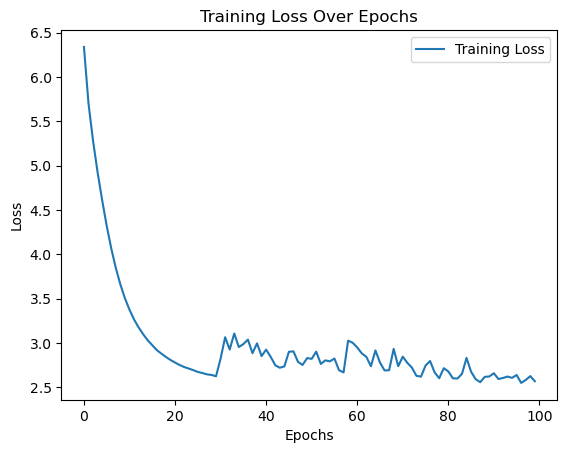

In [121]:
import matplotlib.pyplot as plt
 # Step 2: Plot training loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
# Add title and labels
plt.title('Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
 # Add a legend
plt.legend()
# Display the plot
plt.show()

### RNN Model Results Summary
 
We modeled two layer Recurrent Neural Network (RNN) model, One RNN model and one RNN model with GloVe embeddings.
 
1. **RNN with 1 Layer**  

   - **Epochs**: 100  

   - **Accuracy**:170%
 
2. **RNN with 2 Layers**  

   - **Epochs**: 30  

   - **Accuracy**: 40%
 
3. **RNN with GloVe Embeddings (1 Layer)**  

   - **Epochs**: 100  

   - **Accurac3**:4. **RNN with GloVe Embeddings (2 Layer)**  

   - **Epochs**: 100  

   - **Accuracy**: 51% 40%

 
We ran the predictions with saved model for 1 layer of RNN 
 

### Strategies to Increase Model Accuracy
 
1. **Increase Model Complexity:**
   - **Add More Layers**: Try adding more RNN layers (e.g., stack 2-3 layers).
   - **Use Advanced RNN Architectures**: Switch from `SimpleRNN` to `LSTM` or `GRU` layers, which handle long-term dependencies better.
   - **Increase Units**: Increase the number of units in each RNN layer (e.g., from 150 to 256 or 512).
 
2. **Tuning Hyperparameters:**
   - **Learning Rate**: Experiment with different learning rates (e.g., `0.001`, `0.0001`) to find an optimal learning rate.
   - **Batch Size**: Adjust the batch size (smaller sizes can lead to better generalization).
 
3. **Use Bidirectional RNNs:**
   - Use a `Bidirectional` RNN to allow the model to capture patterns from both past and future contexts.
 
4. **Train for More Epochs:**
   - **Increase Epochs**: Train the model for more epochs, but monitor for overfitting using validation accuracy.
 
5. **Experiment with Optimizers:**
   - Try using different optimizers like **Adam** (default), **RMSprop**, or **Nadam** to see if they improve learning performance.